#  Linear Discriminant Analysis (LDA)

**Author:** Varun Singh

**GitHub:** https://github.com/varunsingh-dev

**Repository:** Machine Learning

**Module:** 09_LDA

**Dataset:** Wine.csv

**Objective:** Reduce the dimensionality of the Wine dataset while maximizing the separation between different wine classes using LDA.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##  Load Dataset

In [2]:
df = pd.read_csv("/content/wine.csv")
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


##  Dataset Shape

In [3]:
df.shape

(178, 14)

##  Dataset Columns

In [5]:
df.columns.tolist()

['Wine',
 'Alcohol',
 'Malic.acid',
 'Ash',
 'Acl',
 'Mg',
 'Phenols',
 'Flavanoids',
 'Nonflavanoid.phenols',
 'Proanth',
 'Color.int',
 'Hue',
 'OD',
 'Proline']

##  Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


##  Statistical Summary

In [7]:
df.describe()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


##  Check Missing Values

In [8]:
df.isnull().sum()

,0
Wine,0
Alcohol,0
Malic.acid,0
Ash,0
Acl,0
Mg,0
Phenols,0
Flavanoids,0
Nonflavanoid.phenols,0
Proanth,0


##  Separate Features and Target

In [9]:
X = df.drop("Wine",axis=1)
y = df["Wine"]
print("Feature Shape:",X.shape)
print("Target shape:",y.shape)

Feature Shape: (178, 13)
Target shape: (178,)


##  Feature Scaling

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)
X_scaled.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


##  Apply Linear Discriminant Analysis

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

X_lda = lda.fit_transform(X_scaled, y)

print("Original Features:", X.shape[1])
print("LDA Components:", X_lda.shape[1])

Original Features: 13
LDA Components: 2


##  Explained Variance Ratio

In [12]:
explained_variance = lda.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

print("\nTotal Explained Variance:",
      explained_variance.sum())

Explained Variance Ratio:
[0.68747889 0.31252111]

Total Explained Variance: 1.0


##  LDA Transformed Data

In [13]:
lda_df = pd.DataFrame(
    X_lda,
    columns=["LD1", "LD2"]
)

lda_df["Wine"] = y.values

lda_df.head()

,LD1,LD2,Wine
0,-4.700244,1.979138,1
1,-4.301958,1.170413,1
2,-3.420720,1.429101,1
3,-4.205754,4.002871,1
4,-1.509982,0.451224,1


##  LDA 2D Visualization

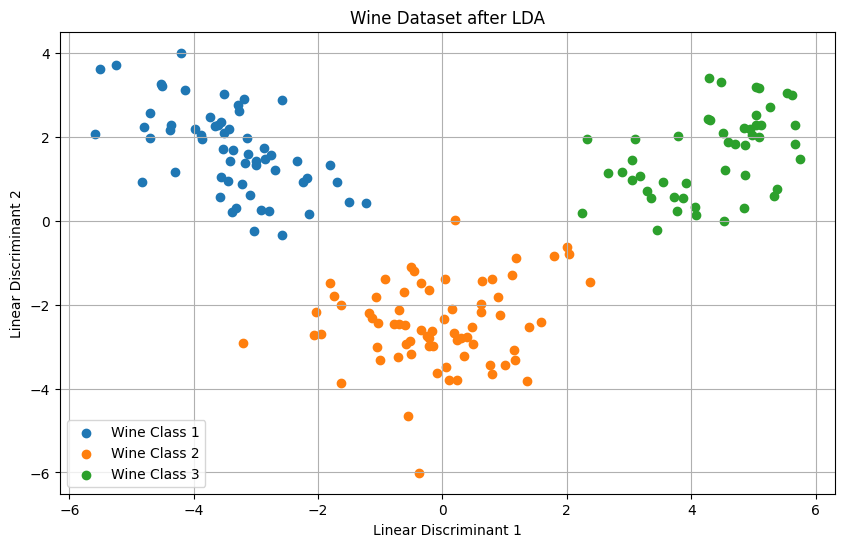

In [14]:
plt.figure(figsize=(10, 6))

for wine_class in sorted(lda_df["Wine"].unique()):
    class_data = lda_df[lda_df["Wine"] == wine_class]

    plt.scatter(
        class_data["LD1"],
        class_data["LD2"],
        label=f"Wine Class {wine_class}"
    )

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("Wine Dataset after LDA")
plt.legend()
plt.grid(True)

plt.show()

##  LDA Component Coefficients

In [15]:
lda_coefficients = pd.DataFrame(
    lda.scalings_[:, :2],
    index=X.columns,
    columns=["LD1", "LD2"]
)

lda_coefficients

,LD1,LD2
Alcohol,-0.326569,0.705754
Malic.acid,0.184094,0.340194
Ash,-0.100969,0.641759
Acl,0.515503,-0.487473
Mg,-0.030813,-0.006591
Phenols,0.385720,-0.020104
Flavanoids,-1.654628,-0.490054
Nonflavanoid.phenols,-0.185636,-0.202407
Proanth,0.076533,-0.175270
Color.int,0.820805,0.585410


##  Final Reduced Dataset

In [16]:
lda_df.head(10)

,LD1,LD2,Wine
0,-4.700244,1.979138,1
1,-4.301958,1.170413,1
2,-3.420720,1.429101,1
3,-4.205754,4.002871,1
4,-1.509982,0.451224,1
5,-4.518689,3.213138,1
6,-4.527378,3.269122,1
7,-4.148348,3.104118,1
8,-3.860829,1.953383,1
9,-3.366624,1.678643,1


##  LDA Explained Variance

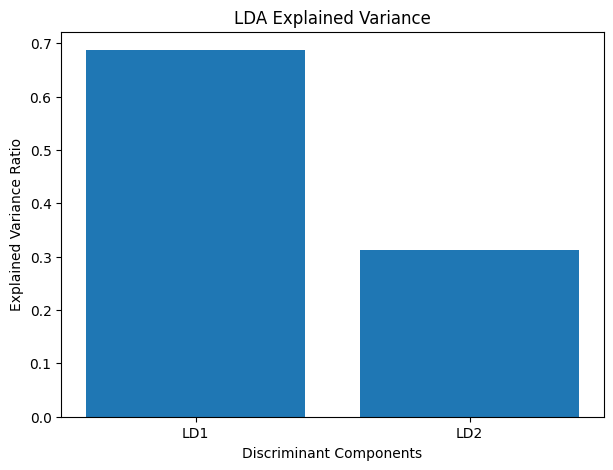

In [17]:
plt.figure(figsize=(7, 5))

components = ["LD1", "LD2"]

plt.bar(
    components,
    lda.explained_variance_ratio_
)

plt.xlabel("Discriminant Components")
plt.ylabel("Explained Variance Ratio")
plt.title("LDA Explained Variance")

plt.show()

##  PCA vs LDA

In [18]:
comparison = pd.DataFrame({
    "Technique": ["PCA", "LDA"],
    "Type": ["Unsupervised", "Supervised"],
    "Components Used": [2, 2]
})

comparison

,Technique,Type,Components Used
0,PCA,Unsupervised,2
1,LDA,Supervised,2


##  PCA vs LDA — Key Difference

| Feature | PCA | LDA |
|---|---|---|
| Learning Type | Unsupervised | Supervised |
| Uses Target Labels | No | Yes |
| Main Objective | Maximize Variance | Maximize Class Separation |
| Wine Dataset | Reduces Features | Separates Wine Classes |
| Maximum Components | Depends on Features | Number of Classes - 1 |

##  Final LDA Visualization

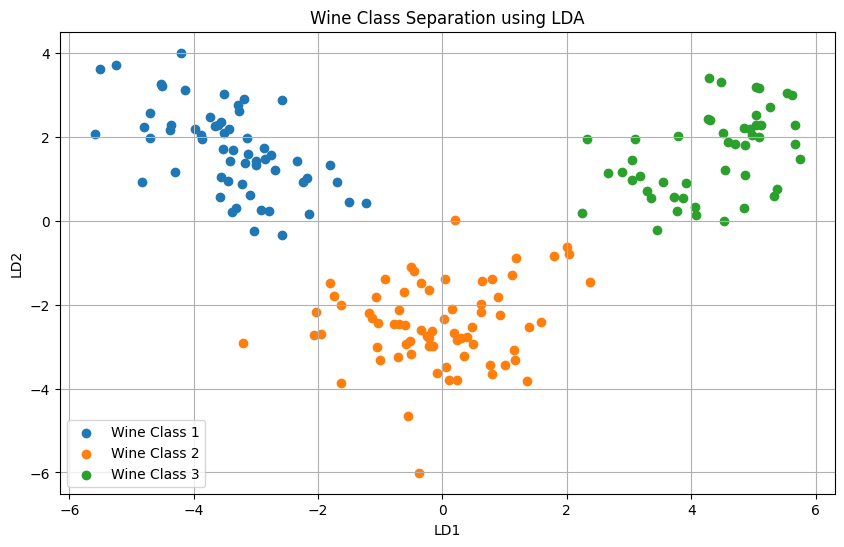

In [19]:
plt.figure(figsize=(10, 6))

for wine_class in sorted(lda_df["Wine"].unique()):
    class_data = lda_df[lda_df["Wine"] == wine_class]

    plt.scatter(
        class_data["LD1"],
        class_data["LD2"],
        label=f"Wine Class {wine_class}"
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Wine Class Separation using LDA")
plt.legend()
plt.grid(True)

plt.show()

# ✅ Key Learnings

- Understood supervised dimensionality reduction.
- Loaded and explored the Wine dataset.
- Identified features and target labels.
- Standardized the numerical features.
- Applied Linear Discriminant Analysis.
- Reduced 13 original features to 2 discriminant components.
- Analyzed explained variance.
- Visualized wine classes in two dimensions.
- Examined LDA component coefficients.
- Compared PCA and LDA.

## 🎯 Project Summary

In this project, Linear Discriminant Analysis (LDA) was applied to the Wine dataset.

The original 13 numerical features were transformed into two discriminant components. Unlike PCA, LDA uses the known wine classes to find directions that maximize class separation.

The resulting 2D visualization helps demonstrate how LDA can make different classes more distinguishable while reducing the dimensionality of the dataset.